# Notebook 02 — Escalado, PCA y selección de rasgos

**Proyecto final de Fundamentos de Inteligencia Artificial · Universidad EIA (2026-2)**

En este notebook decidimos **dos cosas** para los modelos del notebook 03: qué escalador usar y con qué rasgos nos quedamos. Solo leemos `data/train.csv`; **el conjunto de test no se toca** hasta la evaluación final del notebook 04.

Para comparar las opciones usamos siempre el mismo modelo de referencia, una regresión logística con `class_weight='balanced'`, y la misma validación cruzada de 10 particiones. Todo lo que aprende de los datos (el escalador y los selectores de rasgos) va **dentro del pipeline**, para que se ajuste solo con la parte de entrenamiento de cada partición.

Deja listos `models/decisiones_preprocesamiento.joblib` y `resultados/comparacion_rasgos.csv`.

In [21]:
# Si corremos en Google Colab ponemos True; en el computador (VS Code), False
EN_COLAB = False

if EN_COLAB:
    # En Colab hay que instalar lo que no viene de fábrica, y se repite en cada sesión nueva
    !pip install phik shap gradio imbalanced-learn -q
    # En Colab los archivos viven en Drive, así que primero lo montamos
    from google.colab import drive
    drive.mount('/content/drive')
    RUTA_BASE = '/content/drive/MyDrive/Proyecto_Sismos/'
else:
    RUTA_BASE = './'

# Todas las rutas del notebook salen de aquí, para no tener rutas regadas por el código
RUTA_DATOS = RUTA_BASE + 'data/'
RUTA_MODELOS = RUTA_BASE + 'models/'
RUTA_RESULTADOS = RUTA_BASE + 'resultados/'
RUTA_FIGURAS = RUTA_BASE + 'figuras/'

In [22]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import (VarianceThreshold, SelectKBest, f_classif, mutual_info_classif,
                                       RFECV, SequentialFeatureSelector, SelectFromModel)

# Por si las carpetas de salida no existen (por ejemplo, en una carpeta nueva de Drive)
os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_RESULTADOS, exist_ok=True)
os.makedirs(RUTA_FIGURAS, exist_ok=True)

## Cargar los datos de entrenamiento

Leemos solo `train.csv`, que dejó listo el notebook 01 (ya con las categóricas codificadas). Separamos los rasgos (`X_train`) de la clase (`y_train`). La clase nunca entra como rasgo.

In [23]:
train = pd.read_csv(RUTA_DATOS + 'train.csv')
X_train = train.drop(columns=['class'])
y_train = train['class']

n_rasgos = X_train.shape[1]
print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('Turnos peligrosos en train:', y_train.sum(), '(' + str(round(y_train.mean() * 100, 2)) + '%)')

# Las cuatro categóricas ya vienen como números ordinales; las demás son numéricas de verdad
columnas_categoricas = ['seismic', 'seismoacoustic', 'shift', 'ghazard']
columnas_numericas = []
for columna in X_train.columns:
    if columna not in columnas_categoricas:
        columnas_numericas.append(columna)
print(n_rasgos, 'rasgos en total,', len(columnas_numericas), 'numéricos')

X_train: (2062, 15) | y_train: (2062,)
Turnos peligrosos en train: 136 (6.6%)
15 rasgos en total, 11 numéricos


## Validación cruzada y función de evaluación

Definimos la validación cruzada (`StratifiedKFold` de 10 particiones, igual que en clase), las métricas que vamos a reportar y la función `evaluar_cv`, que recibe un pipeline y devuelve sus métricas promedio. Esta función se copia **idéntica** en los notebooks 03 y 04.

Un detalle: con tan pocos turnos peligrosos, a veces un modelo no predice ninguno en una partición y la precisión queda indefinida. Por eso usamos `zero_division=0`, que la cuenta como 0 en vez de lanzar una advertencia.

In [24]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Con tan pocos turnos peligrosos, a veces un modelo no predice ninguno en una partición y la precisión
# queda indefinida (scikit-learn lanza una advertencia). Con zero_division=0 la contamos como 0 y seguimos.
metricas = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

def evaluar_cv(pipeline, X, y, nombre):
    """
    Evalúa un pipeline con validación cruzada estratificada de 10 particiones.
    Devuelve un diccionario con el promedio de cada métrica, la desviación del F1, el F1 de cada
    partición (para los box plots) y el tiempo que tardó. Se agrega a la lista rows para armar la tabla.
    """
    inicio = time.time()
    resultados = cross_validate(pipeline, X, y, cv=cv, scoring=metricas, n_jobs=-1)
    return {
        'Nombre': nombre,
        'Accuracy': resultados['test_accuracy'].mean(),
        'Precision': resultados['test_precision'].mean(),
        'Recall': resultados['test_recall'].mean(),
        'F1': resultados['test_f1'].mean(),
        'F1_std': resultados['test_f1'].std(),
        'ROC_AUC': resultados['test_roc_auc'].mean(),
        'F1_por_particion': resultados['test_f1'],
        'Tiempo_s': time.time() - inicio,
    }

**Modelo de referencia.** En todo el notebook usamos `LogisticRegression(max_iter=2000, class_weight='balanced')`, como en el notebook de selección de rasgos de clase. Le ponemos `class_weight='balanced'` porque sin él casi no predice turnos peligrosos y todas las comparaciones darían un F1 cercano a 0. La comparación de verdad entre estrategias de balanceo la hacemos en el notebook 03.

## Escalado

Las variables están en escalas muy distintas: `genergy` llega a millones y `nbumps` a 9. Vamos a comparar tres opciones: dejar los datos como están, `MinMaxScaler` (los lleva a [0, 1]) y `StandardScaler` (media 0 y desviación 1). Primero armamos dos funciones auxiliares y miramos los box plots de las numéricas con cada opción. El escalador se ajusta solo con train; aquí lo usamos únicamente para graficar.

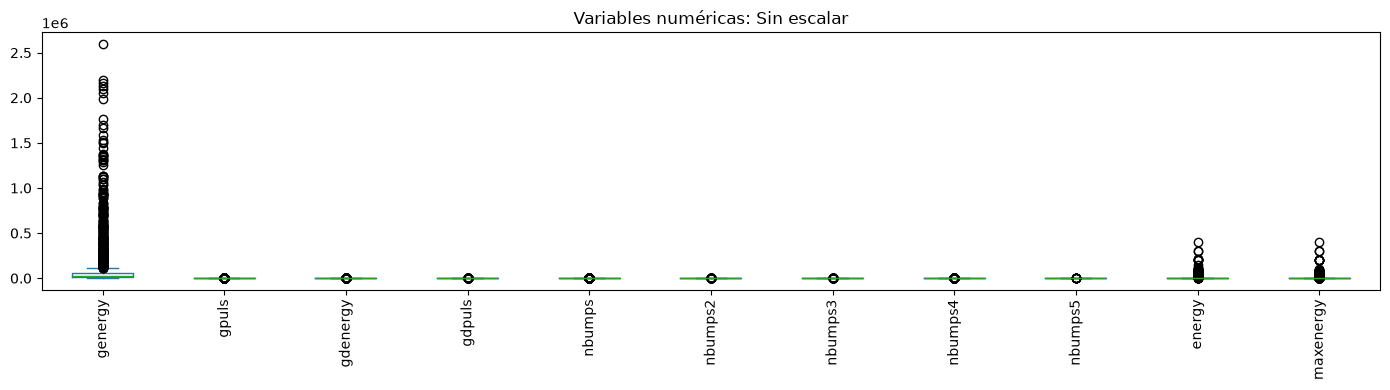

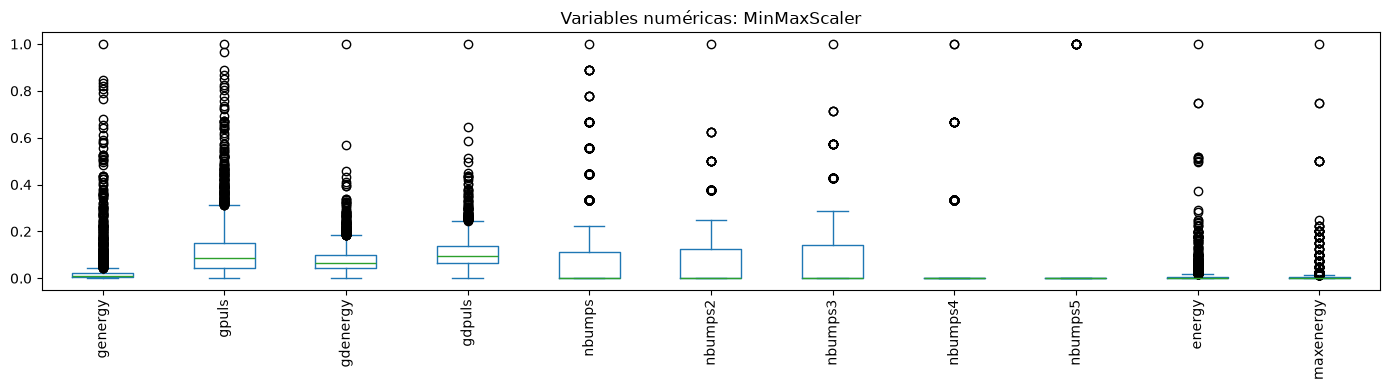

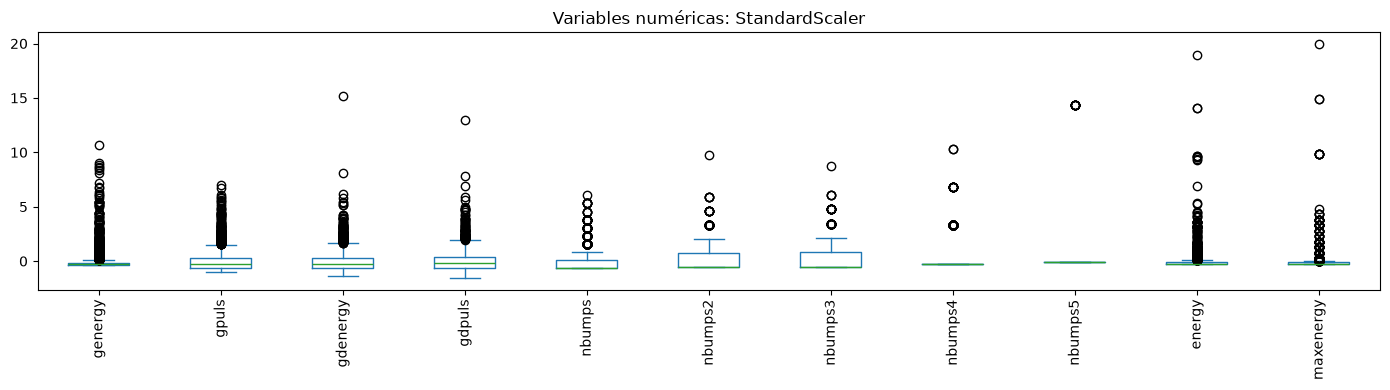

In [25]:
def crear_escalador(nombre):
    """Devuelve un escalador nuevo según el nombre que guardamos en el notebook 02."""
    if nombre == 'MinMaxScaler':
        return MinMaxScaler()
    elif nombre == 'StandardScaler':
        return StandardScaler()
    return 'passthrough'   # 'Sin escalar': el pipeline deja pasar los datos tal cual

def aplicar_escalador(X, nombre_escalador):
    """
    Ajusta el escalador con los datos que recibe y devuelve esos datos escalados como arreglo de numpy.
    Si el nombre es 'Sin escalar', devuelve los datos sin cambios. La usamos para graficar y para el PCA;
    en los modelos el escalador va dentro del pipeline.
    """
    escalador = crear_escalador(nombre_escalador)
    if escalador == 'passthrough':
        return X.values
    return escalador.fit_transform(X)

def graficar_boxplots(df, titulo, nombre_archivo):
    """
    Dibuja un box plot por cada columna del DataFrame y guarda la figura en la ruta `nombre_archivo`.
    Sirve para ver de un vistazo qué tan distintas son las escalas de las variables antes y después de escalar.
    """
    df.plot.box(figsize=(14, 4), rot=90)
    plt.title(titulo)
    plt.tight_layout()
    plt.savefig(nombre_archivo, bbox_inches='tight', dpi=150)
    plt.show()

for nombre_escalador in ['Sin escalar', 'MinMaxScaler', 'StandardScaler']:
    datos_escalados = pd.DataFrame(aplicar_escalador(X_train[columnas_numericas], nombre_escalador),
                                   columns=columnas_numericas)
    graficar_boxplots(datos_escalados, 'Variables numéricas: ' + nombre_escalador,
                      RUTA_FIGURAS + '02_boxplots_' + nombre_escalador + '.png')

**Lo que notamos.** Sin escalar, el box plot de `genergy` (que llega a millones) aplasta a todas las demás variables y casi no se alcanza a ver su forma. Con `MinMaxScaler` todas quedan entre 0 y 1, pero justo por los valores extremos que decidimos conservar, las cajas de `genergy`, `energy` y `maxenergy` quedan pegadas a 0 y solo se ven los puntos extremos arriba. Con `StandardScaler` la media queda en 0, pero los extremos siguen siendo igual de lejanos. Ninguna opción arregla los extremos, así que la decisión se toma con los números de la validación cruzada.

Ahora comparamos con validación cruzada los tres escaladores con dos modelos sensibles a la escala: la regresión logística de referencia y una `SVC` con `class_weight='balanced'`. Son 6 combinaciones. Elegimos el escalador con mejor F1 promedio entre los dos modelos, para que la decisión no dependa de un solo modelo.

In [26]:
rows = []
for nombre_escalador in ['Sin escalar', 'MinMaxScaler', 'StandardScaler']:
    modelos_referencia = [
        ('Regresión logística', LogisticRegression(max_iter=2000, class_weight='balanced')),
        ('SVM', SVC(class_weight='balanced', random_state=42)),
    ]
    for nombre_modelo, modelo in modelos_referencia:
        pipeline = Pipeline([('escalador', crear_escalador(nombre_escalador)), ('clf', modelo)])
        fila = evaluar_cv(pipeline, X_train, y_train, nombre_escalador + ' | ' + nombre_modelo)
        fila['Escalador'] = nombre_escalador
        fila['Modelo'] = nombre_modelo
        rows.append(fila)
        print(nombre_escalador, '|', nombre_modelo, '-> F1 =', round(fila['F1'], 3))

tabla_escalado = pd.DataFrame(rows)

# Promedio del F1 de los dos modelos para cada escalador; el que tenga el más alto es el elegido
promedios_f1 = tabla_escalado.groupby('Escalador')['F1'].mean()
escalador_elegido = promedios_f1.idxmax()
print('\nF1 promedio por escalador:')
print(promedios_f1.round(4))
print('Escalador elegido:', escalador_elegido)
tabla_escalado[['Escalador', 'Modelo', 'F1', 'F1_std', 'Recall', 'Precision', 'ROC_AUC', 'Accuracy', 'Tiempo_s']]

Sin escalar | Regresión logística -> F1 = 0.25
Sin escalar | SVM -> F1 = 0.225
MinMaxScaler | Regresión logística -> F1 = 0.269
MinMaxScaler | SVM -> F1 = 0.262
StandardScaler | Regresión logística -> F1 = 0.259
StandardScaler | SVM -> F1 = 0.257

F1 promedio por escalador:
Escalador
MinMaxScaler      0.2656
Sin escalar       0.2378
StandardScaler    0.2580
Name: F1, dtype: float64
Escalador elegido: MinMaxScaler


,Escalador,Modelo,F1,F1_std,Recall,Precision,ROC_AUC,Accuracy,Tiempo_s
0,Sin escalar,Regresión logística,0.250261,0.044852,0.602747,0.158199,0.746376,0.762347,18.566267
1,Sin escalar,SVM,0.225306,0.059597,0.529121,0.143457,0.720095,0.758492,2.247153
2,MinMaxScaler,Regresión logística,0.269292,0.043370,0.669231,0.168817,0.772911,0.758963,0.089314
3,MinMaxScaler,SVM,0.261851,0.059815,0.602198,0.168133,0.729652,0.774980,0.295702
4,StandardScaler,Regresión logística,0.258678,0.047553,0.632418,0.162903,0.760936,0.760408,0.096041
5,StandardScaler,SVM,0.257351,0.033816,0.543956,0.169859,0.712197,0.794391,0.260489


**Lo que notamos.** Con la regresión logística el F1 fue 0,250 sin escalar, 0,269 con MinMax y 0,259 con Standard; con la SVM fue 0,225, 0,262 y 0,257. El promedio de los dos modelos dejó a `MinMaxScaler` primero (0,2656), después `StandardScaler` (0,2580) y al final sin escalar (0,2378), así que el escalador elegido es **MinMaxScaler**. Esperábamos que los extremos le hicieran daño al MinMax, y no fue así; aun así las diferencias son pequeñas comparadas con la desviación del F1 entre particiones (entre 0,03 y 0,06), así que no hay que leerlas como una victoria clara.

Sí vemos un efecto práctico: la SVM sin escalar tardó unos 9 segundos y escalada menos de uno. También vale la pena fijarse en que el accuracy de estos modelos está entre 0,76 y 0,79, bastante por debajo del 93% del modelo que siempre dice "sin peligro". Es el precio de usar `class_weight='balanced'`: el modelo acepta equivocarse más en los turnos tranquilos para detectar más turnos peligrosos (el recall de la regresión logística con MinMax fue 0,669).

## PCA

Con el escalador elegido miramos cuánta varianza explica cada componente. Dibujamos la varianza acumulada con líneas en 0,90 y 0,95, como en `PCA_Wine`, y contamos cuántas componentes hacen falta para llegar a cada nivel. Aquí ajustamos el PCA con todo train solo para describir los datos; cuando lo evaluemos con modelos va dentro del pipeline.

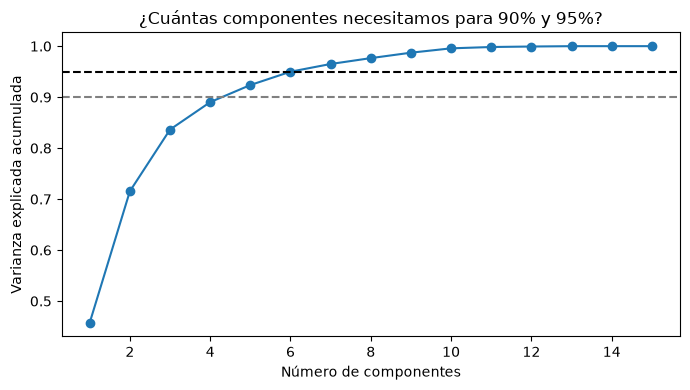

Componentes para llegar al 90% de la varianza: 5
Componentes para llegar al 95% de la varianza: 7
Varianza de las dos primeras componentes: [0.458 0.258]


In [27]:
X_train_escalado = aplicar_escalador(X_train, escalador_elegido)

pca_completo = PCA(svd_solver='full').fit(X_train_escalado)
varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o')
plt.axhline(0.90, linestyle='--', color='gray')
plt.axhline(0.95, linestyle='--', color='black')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('¿Cuántas componentes necesitamos para 90% y 95%?')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + '02_pca_varianza_acumulada.png', bbox_inches='tight', dpi=150)
plt.show()

# argmax devuelve la primera posición donde se cumple la condición; sumamos 1 porque las posiciones empiezan en 0
n_componentes_90 = int(np.argmax(varianza_acumulada >= 0.90)) + 1
n_componentes_95 = int(np.argmax(varianza_acumulada >= 0.95)) + 1
print('Componentes para llegar al 90% de la varianza:', n_componentes_90)
print('Componentes para llegar al 95% de la varianza:', n_componentes_95)
print('Varianza de las dos primeras componentes:', np.round(pca_completo.explained_variance_ratio_[:2], 3))

**Lo que notamos.** Hacen falta 5 componentes para llegar al 90% de la varianza y 7 para el 95%, de un total de 15 rasgos. Solo la primera componente explica el 45,8% y la segunda el 25,8%. O sea que hay bastante información repetida entre los rasgos, algo que ya sospechábamos por la correlación de phik en el notebook 01.

Ahora proyectamos los turnos en las dos primeras componentes y los pintamos por clase. Dibujamos primero los turnos sin peligro y después los peligrosos, para que estos últimos no queden tapados.

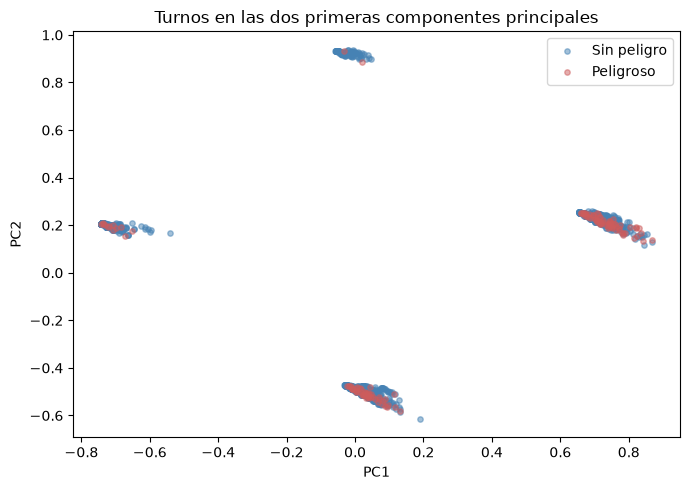

In [28]:
componentes_2d = PCA(n_components=2, svd_solver='full').fit_transform(X_train_escalado)

plt.figure(figsize=(7, 5))
for clase, nombre_clase, color in [(0, 'Sin peligro', 'steelblue'), (1, 'Peligroso', 'indianred')]:
    posiciones = (y_train == clase).values
    plt.scatter(componentes_2d[posiciones, 0], componentes_2d[posiciones, 1], label=nombre_clase, color=color, alpha=0.5, s=15)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Turnos en las dos primeras componentes principales')
plt.legend()
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + '02_pca_2d_por_clase.png', bbox_inches='tight', dpi=150)
plt.show()

**Lo que notamos.** En las dos primeras componentes los turnos forman cuatro grupos bien separados. Sospechamos que esos grupos salen de las categóricas codificadas (`shift`, `seismic`), que al escalar pesan mucho en la varianza, y no de que haya peligro o no. Lo importante es que **dentro de cada grupo los puntos rojos (peligrosos) quedan mezclados con los azules**: las dos primeras componentes no separan las clases. Esto ayuda a entender por qué el problema es difícil: no hay una dirección simple en los datos que distinga los turnos peligrosos.

Por último comparamos con `evaluar_cv` tres opciones, todas con el escalador elegido y la regresión logística de referencia: todos los rasgos, PCA que conserva el 90% de la varianza y PCA que conserva el 95%.

In [29]:
rows = []
opciones_pca = [
    ('Todos los rasgos', 'passthrough'),
    ('PCA 90%', PCA(n_components=0.90, svd_solver='full')),
    ('PCA 95%', PCA(n_components=0.95, svd_solver='full')),
]
for nombre_opcion, paso_pca in opciones_pca:
    pipeline = Pipeline([('escalador', crear_escalador(escalador_elegido)),
                         ('pca', paso_pca),
                         ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))])
    fila = evaluar_cv(pipeline, X_train, y_train, nombre_opcion)
    rows.append(fila)
    print(nombre_opcion, '-> F1 =', round(fila['F1'], 3))

tabla_pca = pd.DataFrame(rows)
tabla_pca[['Nombre', 'F1', 'F1_std', 'Recall', 'Precision', 'ROC_AUC', 'Accuracy']]

Todos los rasgos -> F1 = 0.269
PCA 90% -> F1 = 0.264
PCA 95% -> F1 = 0.267


,Nombre,F1,F1_std,Recall,Precision,ROC_AUC,Accuracy
0,Todos los rasgos,0.269292,0.043370,0.669231,0.168817,0.772911,0.758963
1,PCA 90%,0.263718,0.054422,0.674725,0.164038,0.774863,0.750225
2,PCA 95%,0.266919,0.048639,0.675824,0.166521,0.773662,0.753626


**Lo que notamos.** Con todos los rasgos el F1 fue 0,269 (desviación 0,043), con PCA al 90% fue 0,264 (0,054) y con PCA al 95% fue 0,267 (0,049). El recall y el ROC AUC también quedan casi iguales (recall entre 0,669 y 0,676; ROC AUC entre 0,773 y 0,775). Es decir, PCA no mejora nada.

**Decisión: no usamos PCA.** Con apenas 15 rasgos no ganamos rendimiento y perdemos la interpretación, porque cada componente mezcla varios rasgos y ya no podríamos decirle a nadie qué variable pesa en el peligro. Además la app necesita pedir datos reales del turno.

## Selección de rasgos

Probamos los mismos métodos del notebook de clase y también la importancia con SHAP. Todos se evalúan con el escalador elegido y la regresión logística de referencia. Para que la comparación sea justa armamos dos funciones:

La primera, `evaluar_selector`, mete el selector **dentro del pipeline**. Así, en cada partición de la validación cruzada el selector escoge los rasgos solo con la parte de entrenamiento, y el F1 que reportamos no está inflado por haber mirado los datos de validación. La segunda, `evaluar_conjunto`, evalúa una lista fija de rasgos; la usamos para la línea base (todos los rasgos) y para los métodos que no se pueden meter en un pipeline sin escribir una clase propia (VarianceThreshold, que no mira la clase, y SHAP).

También definimos `mejor_fila`, que escoge la fila de mayor F1 de una lista, y `info_mutua`, que es `mutual_info_classif` con la semilla fija para que el resultado sea siempre el mismo.

In [30]:
def crear_pipeline_rasgos(selector, nombre_escalador):
    """
    Arma el pipeline de comparación: escalador -> selector de rasgos -> regresión logística de referencia.
    Recibe el selector (o 'passthrough' si no hay) y el nombre del escalador elegido. Devuelve el pipeline.
    """
    return Pipeline([
        ('escalador', crear_escalador(nombre_escalador)),
        ('seleccion', selector),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced')),
    ])

def evaluar_selector(selector, nombre, X, y, nombre_escalador):
    """
    Evalúa con validación cruzada un selector de rasgos metido dentro del pipeline y devuelve su fila de resultados.
    Además ajusta el pipeline con todo train una vez, solo para saber qué rasgos escogió el selector, y lo
    guarda en la fila ('Pipeline_ajustado') por si queremos mirar algo más del selector (por ejemplo la curva del RFECV).
    """
    pipeline = crear_pipeline_rasgos(selector, nombre_escalador)
    fila = evaluar_cv(pipeline, X, y, nombre)
    pipeline.fit(X, y)
    mascara = pipeline.named_steps['seleccion'].get_support()
    rasgos = []
    for columna, escogido in zip(X.columns, mascara):
        if escogido:
            rasgos.append(columna)
    fila['Metodo'] = nombre
    fila['N_rasgos'] = len(rasgos)
    fila['Rasgos'] = rasgos
    fila['Pipeline_ajustado'] = pipeline
    fila['Seleccion_en_pipeline'] = True   # el selector se ajustó dentro de cada partición: sin filtración
    return fila

def evaluar_conjunto(rasgos, nombre, X, y, nombre_escalador):
    """
    Evalúa con validación cruzada una lista fija de rasgos (escalador -> regresión logística de referencia)
    y devuelve su fila de resultados. Recibe los nombres de las columnas, un nombre para la fila, los datos
    de entrenamiento y el nombre del escalador.
    """
    pipeline = crear_pipeline_rasgos('passthrough', nombre_escalador)
    fila = evaluar_cv(pipeline, X[rasgos], y, nombre)
    fila['Metodo'] = nombre
    fila['N_rasgos'] = len(rasgos)
    fila['Rasgos'] = rasgos
    fila['Seleccion_en_pipeline'] = False   # los rasgos ya venían escogidos con todo train
    return fila

def mejor_fila(filas):
    """
    Devuelve la fila con mayor F1 de una lista de filas. Si hay empate, gana la que usa menos rasgos.
    La usamos para escoger el mejor k en los métodos que se prueban con un ciclo sobre k.
    """
    mejor = filas[0]
    for fila in filas:
        if fila['F1'] > mejor['F1'] or (fila['F1'] == mejor['F1'] and fila['N_rasgos'] < mejor['N_rasgos']):
            mejor = fila
    return mejor

def info_mutua(X, y):
    """
    Calcula la información mutua de cada rasgo con la clase, con semilla fija (random_state=42).
    Es una función normal porque SelectKBest necesita una que reciba (X, y), y así el resultado no cambia
    entre ejecuciones.
    """
    return mutual_info_classif(X, y, random_state=42)

# Aquí acumulamos la fila "ganadora" de cada método para la tabla comparativa del final
rows = []

# Línea base: todos los rasgos
fila_base = evaluar_conjunto(list(X_train.columns), 'Todos los rasgos', X_train, y_train, escalador_elegido)
rows.append(fila_base)
print('Todos los rasgos -> F1 =', round(fila_base['F1'], 3), '| rasgos:', fila_base['N_rasgos'])

Todos los rasgos -> F1 = 0.269 | rasgos: 15


### a) VarianceThreshold

Este método quita las columnas que casi nunca cambian. Lo aplicamos sobre los datos escalados a [0, 1] con `threshold=0.01`, porque la varianza depende de la escala y así todas las columnas se miden con la misma vara. No usa la clase, por eso no hay riesgo de filtración si lo ajustamos con todo train.

In [31]:
datos_minmax = MinMaxScaler().fit_transform(X_train)
selector_varianza = VarianceThreshold(threshold=0.01).fit(datos_minmax)

rasgos_varianza = []
descartados_varianza = []
for columna, varianza, escogido in zip(X_train.columns, selector_varianza.variances_, selector_varianza.get_support()):
    if escogido:
        rasgos_varianza.append(columna)
    else:
        descartados_varianza.append(columna)
        print('Varianza de', columna, 'con MinMax:', round(varianza, 5))

fila_varianza = evaluar_conjunto(rasgos_varianza, 'VarianceThreshold', X_train, y_train, escalador_elegido)
rows.append(fila_varianza)
print('Descartados:', descartados_varianza)
print('VarianceThreshold -> F1 =', round(fila_varianza['F1'], 3), '| rasgos:', fila_varianza['N_rasgos'])

Varianza de genergy con MinMax: 0.00815
Varianza de gdenergy con MinMax: 0.00367
Varianza de gdpuls con MinMax: 0.00473
Varianza de nbumps2 con MinMax: 0.00952
Varianza de nbumps4 con MinMax: 0.00896
Varianza de nbumps5 con MinMax: 0.00483
Varianza de energy con MinMax: 0.00272
Varianza de maxenergy con MinMax: 0.00246
Descartados: ['genergy', 'gdenergy', 'gdpuls', 'nbumps2', 'nbumps4', 'nbumps5', 'energy', 'maxenergy']
VarianceThreshold -> F1 = 0.258 | rasgos: 7


**Lo que notamos.** Con `threshold=0.01` sobre los datos en [0, 1], VarianceThreshold descartó 8 de los 15 rasgos: `genergy`, `gdenergy`, `gdpuls`, `nbumps2`, `nbumps4`, `nbumps5`, `energy` y `maxenergy` (todos con varianza entre 0,0025 y 0,0095). Se cayó `nbumps5`, como esperábamos, pero también cayeron variables de energía que no son constantes: lo que pasa es que los pocos valores extremos estiran el rango y, al llevar todo a [0, 1], el resto de los datos queda muy comprimido y parece "casi constante". Quedaron 7 rasgos (`seismic`, `seismoacoustic`, `shift`, `gpuls`, `ghazard`, `nbumps` y `nbumps3`) con un F1 de 0,258, más bajo que el de todos los rasgos (0,269). No parece un criterio muy bueno para este conjunto de datos.

### b) SelectKBest con f_classif y con información mutua

Como en clase, probamos todos los valores de k de 1 hasta el número de rasgos con un ciclo `for`, cada uno evaluado con validación cruzada y con el selector dentro del pipeline. Lo hacemos con dos criterios: `f_classif` (el F de ANOVA) e información mutua. Después graficamos el F1 contra k y nos quedamos con el mejor k de cada criterio.

SelectKBest f_classif listo
SelectKBest info_mutua listo


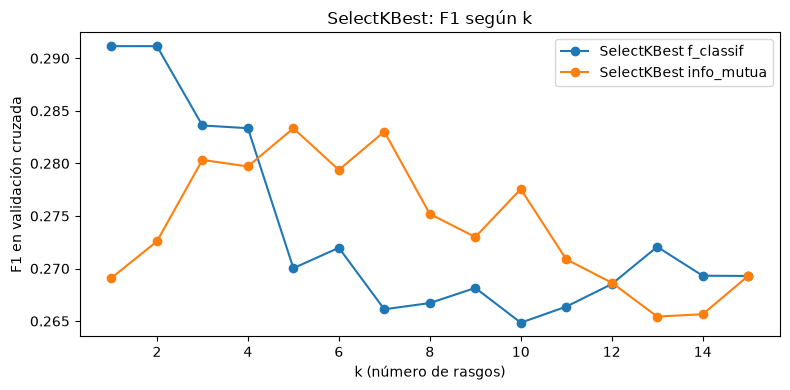

SelectKBest f_classif (k=1) -> F1 = 0.291 | rasgos: ['nbumps']
SelectKBest info_mutua (k=5) -> F1 = 0.283 | rasgos: ['gpuls', 'nbumps', 'nbumps2', 'nbumps3', 'energy']


In [32]:
filas_kbest = []
for nombre_metodo, funcion_score in [('SelectKBest f_classif', f_classif), ('SelectKBest info_mutua', info_mutua)]:
    for k in range(1, n_rasgos + 1):
        fila = evaluar_selector(SelectKBest(funcion_score, k=k), nombre_metodo + ' (k=' + str(k) + ')',
                                X_train, y_train, escalador_elegido)
        fila['Metodo_base'] = nombre_metodo
        fila['k'] = k
        filas_kbest.append(fila)
    print(nombre_metodo, 'listo')

tabla_kbest = pd.DataFrame(filas_kbest)

plt.figure(figsize=(8, 4))
for nombre_metodo in ['SelectKBest f_classif', 'SelectKBest info_mutua']:
    parte = tabla_kbest[tabla_kbest['Metodo_base'] == nombre_metodo]
    plt.plot(parte['k'], parte['F1'], marker='o', label=nombre_metodo)
plt.xlabel('k (número de rasgos)')
plt.ylabel('F1 en validación cruzada')
plt.title('SelectKBest: F1 según k')
plt.legend()
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + '02_selectkbest_f1_vs_k.png', bbox_inches='tight', dpi=150)
plt.show()

# El mejor k de cada criterio pasa a la tabla comparativa
for nombre_metodo in ['SelectKBest f_classif', 'SelectKBest info_mutua']:
    candidatas = []
    for fila in filas_kbest:
        if fila['Metodo_base'] == nombre_metodo:
            candidatas.append(fila)
    ganadora = mejor_fila(candidatas)
    ganadora['Metodo'] = nombre_metodo + ' (k=' + str(ganadora['k']) + ')'
    rows.append(ganadora)
    print(ganadora['Metodo'], '-> F1 =', round(ganadora['F1'], 3), '| rasgos:', ganadora['Rasgos'])

**Lo que notamos.** Con `f_classif` el mejor resultado es con **k = 1**: el F1 es 0,291 usando solo `nbumps`, y de ahí baja hasta rondar 0,265 con k entre 7 y 10. Con información mutua el mejor es k = 5 (`gpuls`, `nbumps`, `nbumps2`, `nbumps3` y `energy`) con F1 de 0,283. Con k = 15, que es usar todos los rasgos, ambos dan 0,269, igual que la línea base, como debe ser. Todas estas diferencias son menores que la desviación del F1 entre particiones (alrededor de 0,07 para estos conjuntos), así que más rasgos no parecen traer una mejora clara.

### c) RFECV

La eliminación recursiva de rasgos con validación cruzada va quitando el rasgo menos importante para la regresión logística y se queda con el número de rasgos que da el mejor F1. Lo configuramos como en clase: `step=1`, `StratifiedKFold(5)` y `scoring='f1'`. Está dentro del pipeline, así que en cada partición de la validación cruzada externa vuelve a escoger los rasgos.

RFECV -> F1 = 0.281 | rasgos: ['nbumps']


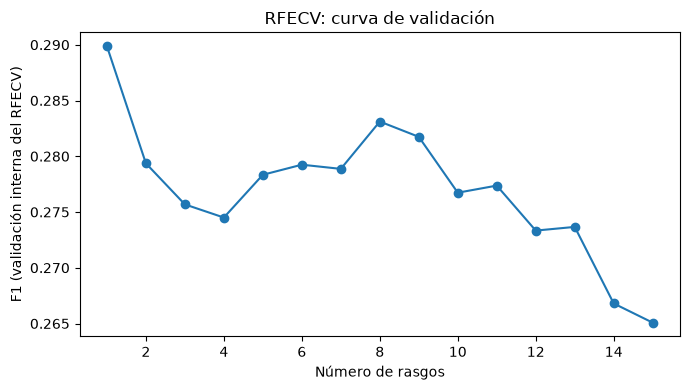

In [33]:
selector_rfecv = RFECV(
    estimator=LogisticRegression(max_iter=2000, class_weight='balanced'),
    step=1,
    cv=StratifiedKFold(5),
    scoring='f1',
    min_features_to_select=1,
)
fila_rfecv = evaluar_selector(selector_rfecv, 'RFECV', X_train, y_train, escalador_elegido)
rows.append(fila_rfecv)
print('RFECV -> F1 =', round(fila_rfecv['F1'], 3), '| rasgos:', fila_rfecv['Rasgos'])

# Curva del F1 interno del RFECV (con todo train) según el número de rasgos que quedan
rfecv_ajustado = fila_rfecv['Pipeline_ajustado'].named_steps['seleccion']
curva_rfecv = rfecv_ajustado.cv_results_['mean_test_score']
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(curva_rfecv) + 1), curva_rfecv, marker='o')
plt.xlabel('Número de rasgos')
plt.ylabel('F1 (validación interna del RFECV)')
plt.title('RFECV: curva de validación')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + '02_rfecv_curva.png', bbox_inches='tight', dpi=150)
plt.show()

**Lo que notamos.** RFECV, que va quitando de a un rasgo, terminó quedándose con **un solo rasgo, `nbumps`**, con un F1 de 0,281. Coincide con lo que mostró SelectKBest con `f_classif`: `nbumps` (el número de golpes sísmicos del turno anterior) es el rasgo que más información trae para esta regresión logística.

### d) SequentialFeatureSelector hacia adelante

Este método empieza sin rasgos y va agregando, de a uno, el que más mejora el F1 de la regresión logística (con validación cruzada interna de 5 particiones). Lo probamos para cada k con un ciclo, como en clase. Es el más lento de todos porque en cada paso prueba todos los rasgos que faltan, y además va dentro de la validación cruzada de 10 particiones; tarda unos minutos.

k = 1 -> F1 = 0.291 | tiempo: 2 s
k = 2 -> F1 = 0.279 | tiempo: 4 s
k = 3 -> F1 = 0.272 | tiempo: 5 s
k = 4 -> F1 = 0.27 | tiempo: 6 s
k = 5 -> F1 = 0.262 | tiempo: 7 s
k = 6 -> F1 = 0.264 | tiempo: 8 s
k = 7 -> F1 = 0.271 | tiempo: 9 s
k = 8 -> F1 = 0.269 | tiempo: 10 s
k = 9 -> F1 = 0.268 | tiempo: 10 s
k = 10 -> F1 = 0.278 | tiempo: 12 s
k = 11 -> F1 = 0.277 | tiempo: 13 s
k = 12 -> F1 = 0.282 | tiempo: 25 s
k = 13 -> F1 = 0.278 | tiempo: 33 s
k = 14 -> F1 = 0.281 | tiempo: 35 s


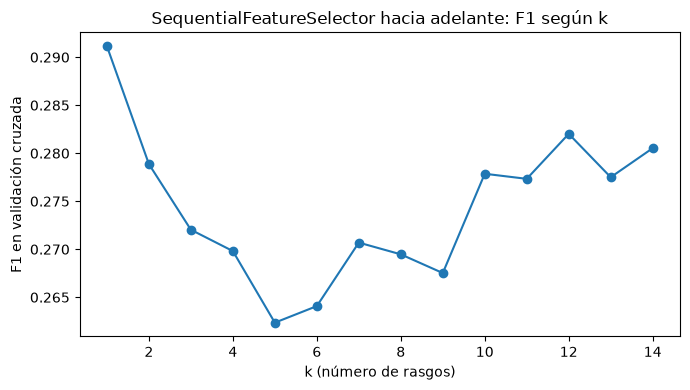

SFS adelante (k=1) -> F1 = 0.291 | rasgos: ['nbumps']


In [34]:
filas_sfs = []
# k llega hasta n_rasgos - 1 porque con todos los rasgos no queda nada por escoger
for k in range(1, n_rasgos):
    selector_sfs = SequentialFeatureSelector(
        LogisticRegression(max_iter=2000, class_weight='balanced'),
        n_features_to_select=k,
        direction='forward',
        scoring='f1',
        cv=5,
    )
    fila = evaluar_selector(selector_sfs, 'SFS adelante (k=' + str(k) + ')', X_train, y_train, escalador_elegido)
    fila['k'] = k
    filas_sfs.append(fila)
    print('k =', k, '-> F1 =', round(fila['F1'], 3), '| tiempo:', round(fila['Tiempo_s']), 's')

tabla_sfs = pd.DataFrame(filas_sfs)

plt.figure(figsize=(7, 4))
plt.plot(tabla_sfs['k'], tabla_sfs['F1'], marker='o')
plt.xlabel('k (número de rasgos)')
plt.ylabel('F1 en validación cruzada')
plt.title('SequentialFeatureSelector hacia adelante: F1 según k')
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + '02_sfs_f1_vs_k.png', bbox_inches='tight', dpi=150)
plt.show()

ganadora_sfs = mejor_fila(filas_sfs)
rows.append(ganadora_sfs)
print(ganadora_sfs['Metodo'], '-> F1 =', round(ganadora_sfs['F1'], 3), '| rasgos:', ganadora_sfs['Rasgos'])

**Lo que notamos.** La selección hacia adelante empieza escogiendo `nbumps` y su mejor F1 es justo con k = 1 (0,291). Al agregar más rasgos el F1 no mejora: baja a 0,279 con 2, 0,262 con 5 y vuelve a subir hasta 0,281 con 14, siempre por debajo de lo que daba `nbumps` solo. Cada k tardó entre 4 y 25 segundos, y todo el ciclo unos pocos minutos. Tres métodos distintos (SelectKBest, RFECV y este) llegan a la misma pista: `nbumps` solo es lo que más rinde, y lo demás casi no suma.

### e) SelectFromModel con L1

La penalización L1 de la regresión logística lleva a cero los coeficientes de los rasgos que menos aportan, y `SelectFromModel` se queda con los que no quedaron en cero. Usamos los mismos parámetros que en clase: `solver='liblinear'` y `C=0.1`, con `class_weight='balanced'`.

In [35]:
selector_l1 = SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', C=0.1, class_weight='balanced'))
fila_l1 = evaluar_selector(selector_l1, 'SelectFromModel L1', X_train, y_train, escalador_elegido)
rows.append(fila_l1)
print('SelectFromModel L1 -> F1 =', round(fila_l1['F1'], 3), '| rasgos:', fila_l1['Rasgos'])

SelectFromModel L1 -> F1 = 0.262 | rasgos: ['seismic', 'seismoacoustic', 'shift', 'gpuls', 'nbumps']


c:\Users\EIA2024\Desktop\Universidad EIA\Sexto Semestre\Fundamentos de Inteligencia Artificial\Trabajo2\prediccion-sismica-minas\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\EIA2024\Desktop\Universidad EIA\Sexto Semestre\Fundamentos de Inteligencia Artificial\Trabajo2\prediccion-sismica-minas\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


**Lo que notamos.** La penalización L1 dejó 5 rasgos (`seismic`, `seismoacoustic`, `shift`, `gpuls` y `nbumps`) con un F1 de 0,262, similar al de todos los rasgos (0,269). Al correr esta celda aparecen advertencias de scikit-learn: dicen que el parámetro `penalty` está marcado como obsoleto desde la versión 1.8. Usamos `penalty='l1'` porque es lo mismo que se hizo en clase, y no ocultamos la advertencia; el texto es confuso, pero el selector sí funciona, porque dejó 10 coeficientes en cero y escogió solo 5 rasgos. Si en el futuro se elimina ese parámetro, habrá que cambiarlo por `l1_ratio`.

### f) SHAP

SHAP mide cuánto empuja cada rasgo las predicciones de un modelo ya entrenado. Entrenamos un `GradientBoostingClassifier` con una muestra de 1.000 turnos de train, calculamos los valores SHAP con `TreeExplainer` y obtenemos la importancia de cada rasgo como el promedio del valor absoluto de sus valores SHAP. Como el problema es binario, los valores salen con forma `(filas, rasgos)`. Después nos quedamos con los rasgos que acumulan el 90% de la importancia total, sumándolos de mayor a menor con un ciclo.

Este método no lo podemos meter en un pipeline sin una clase propia, así que escoge los rasgos una sola vez con train y luego los evaluamos con `evaluar_conjunto`. Por eso su F1 puede quedar un poco más optimista que el de los otros métodos, y lo tendremos en cuenta al leer la tabla.

Forma de los valores SHAP: (1000, 15)


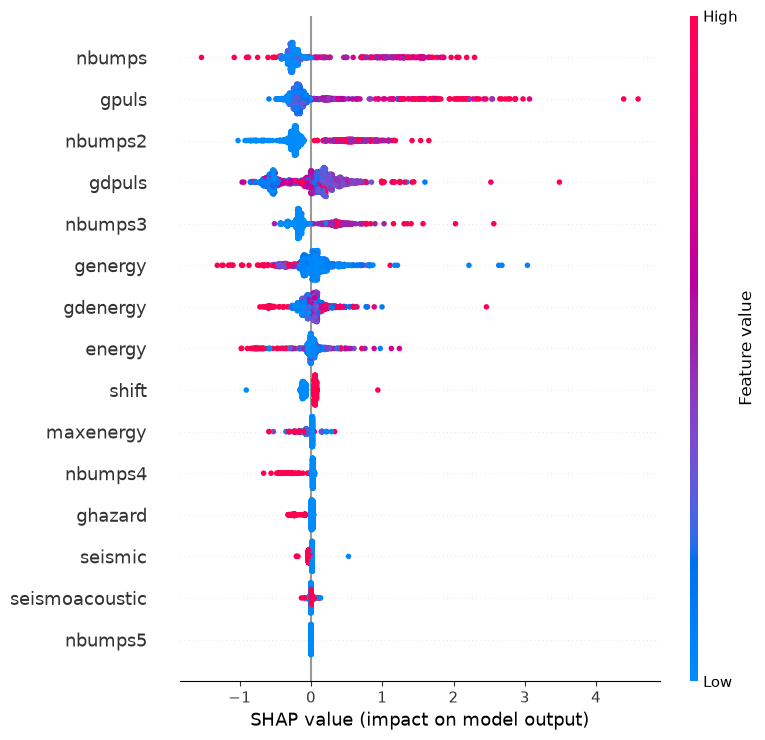

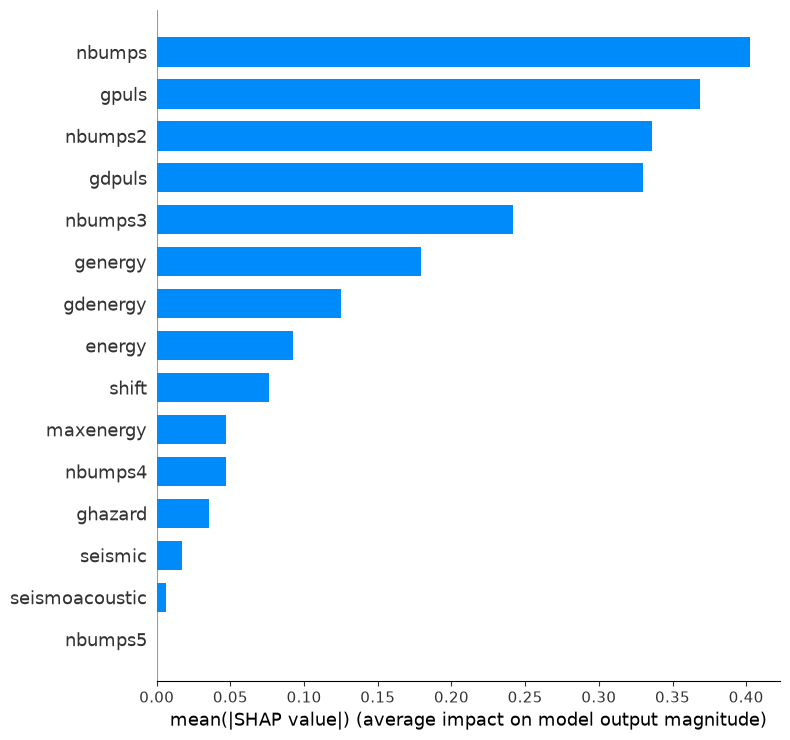

nbumps            0.4028
gpuls             0.3687
nbumps2           0.3359
gdpuls            0.3301
nbumps3           0.2420
genergy           0.1793
gdenergy          0.1250
energy            0.0922
shift             0.0761
maxenergy         0.0471
nbumps4           0.0467
ghazard           0.0354
seismic           0.0175
seismoacoustic    0.0065
nbumps5           0.0000
dtype: float64


In [36]:
muestra_shap = X_train.sample(n=1000, random_state=42)
y_muestra_shap = y_train.loc[muestra_shap.index]

modelo_shap = GradientBoostingClassifier(random_state=42)
modelo_shap.fit(muestra_shap, y_muestra_shap)

explicador = shap.TreeExplainer(modelo_shap)
valores_shap = explicador.shap_values(muestra_shap)
print('Forma de los valores SHAP:', valores_shap.shape)

# Gráfica de puntos (beeswarm): cada punto es un turno y el color es el valor del rasgo
shap.summary_plot(valores_shap, muestra_shap, show=False)
plt.savefig(RUTA_FIGURAS + '02_shap_beeswarm.png', bbox_inches='tight', dpi=150)
plt.show()

# Gráfica de barras con la importancia media absoluta
shap.summary_plot(valores_shap, muestra_shap, plot_type='bar', show=False)
plt.savefig(RUTA_FIGURAS + '02_shap_barras.png', bbox_inches='tight', dpi=150)
plt.show()

importancia_shap = pd.Series(np.abs(valores_shap).mean(axis=0), index=muestra_shap.columns)
importancia_shap = importancia_shap.sort_values(ascending=False)
print(importancia_shap.round(4))

In [37]:
# Sumamos la importancia de mayor a menor hasta llegar al 90% del total
total_importancia = importancia_shap.sum()
acumulado = 0
rasgos_shap = []
for rasgo in importancia_shap.index:
    rasgos_shap.append(rasgo)
    acumulado = acumulado + importancia_shap[rasgo] / total_importancia
    if acumulado >= 0.90:
        break

fila_shap = evaluar_conjunto(rasgos_shap, 'SHAP (90% de la importancia)', X_train, y_train, escalador_elegido)
rows.append(fila_shap)
print('Rasgos que acumulan el 90%:', rasgos_shap, '| importancia acumulada:', round(acumulado, 3))
print('SHAP -> F1 =', round(fila_shap['F1'], 3))

Rasgos que acumulan el 90%: ['nbumps', 'gpuls', 'nbumps2', 'gdpuls', 'nbumps3', 'genergy', 'gdenergy', 'energy'] | importancia acumulada: 0.901
SHAP -> F1 = 0.282


**Lo que notamos.** Según SHAP el rasgo que más pesa es `nbumps` (0,403), seguido de `gpuls` (0,369), `nbumps2` (0,336), `gdpuls` (0,330) y `nbumps3` (0,242); `shift` queda en el puesto 9 (0,076) y `nbumps5` en cero. Llama la atención `gdpuls`, que en phik quedó en 0,000 y aquí aparece cuarto: el modelo de árboles puede aprovechar relaciones que la correlación no ve. Los rasgos que acumulan el 90% de la importancia son 8 (`nbumps`, `gpuls`, `nbumps2`, `gdpuls`, `nbumps3`, `genergy`, `gdenergy` y `energy`) y con ellos el F1 es 0,282. Recordemos que este método escoge sus rasgos una sola vez con train fuera del pipeline, así que su F1 puede salir un poco más optimista.

## Tabla comparativa y decisión

Juntamos la línea base (todos los rasgos) y la mejor versión de cada método en una tabla, con el número de rasgos, el F1, su desviación entre particiones, el recall y el ROC AUC. La guardamos en `resultados/comparacion_rasgos.csv`.

**Regla de decisión.** Al principio habíamos definido la regla del plan: gana el conjunto con mayor F1, y si uno más pequeño queda a menos de una desviación estándar del mejor, gana el más pequeño. Al calcularla vimos que dejaba **un solo rasgo (`nbumps`)**, aunque las diferencias de F1 entre métodos (0,258 a 0,291) caen todas dentro del ruido de la validación cruzada. Con un solo rasgo, además, el notebook 03 casi no tendría qué comparar y la app tendría un único campo. Por eso decidimos en grupo una regla más práctica:

- Solo compiten los métodos cuyo selector corrió **dentro del pipeline**, porque su F1 no está inflado. Quedan fuera la línea base (todos los rasgos), VarianceThreshold y SHAP, que escogen sus rasgos con todo train antes de la validación cruzada.
- El conjunto debe tener **al menos 3 rasgos**.
- Entre los que cumplen, gana el de mayor F1.

In [38]:
tabla_rasgos = pd.DataFrame(rows).sort_values('F1', ascending=False).reset_index(drop=True)

# Para el CSV, la lista de rasgos se guarda como texto separado por comas
rasgos_texto = []
for lista in tabla_rasgos['Rasgos']:
    rasgos_texto.append(', '.join(lista))

tabla_csv = tabla_rasgos[['Metodo', 'N_rasgos', 'F1', 'F1_std', 'Recall', 'Precision', 'ROC_AUC', 'Accuracy']].copy()
tabla_csv['Rasgos'] = rasgos_texto
tabla_csv.to_csv(RUTA_RESULTADOS + 'comparacion_rasgos.csv', index=False)
tabla_csv

,Metodo,N_rasgos,F1,F1_std,Recall,Precision,ROC_AUC,Accuracy,Rasgos
0,SelectKBest f_classif (k=1),1,0.291151,0.070675,0.594505,0.193681,0.743673,0.806970,nbumps
1,SFS adelante (k=1),1,0.291151,0.070675,0.594505,0.193681,0.743673,0.806970,nbumps
2,SelectKBest info_mutua (k=5),5,0.283339,0.068041,0.617582,0.184543,0.767787,0.791930,"gpuls, nbumps, nbumps2, nbumps3, energy"
3,SHAP (90% de la importancia),8,0.281891,0.062031,0.646703,0.180939,0.775039,0.780303,"nbumps, gpuls, nbumps2, gdpuls, nbumps3, gener..."
4,RFECV,1,0.281310,0.064653,0.594505,0.184885,0.742806,0.798734,nbumps
5,Todos los rasgos,15,0.269292,0.043370,0.669231,0.168817,0.772911,0.758963,"seismic, seismoacoustic, shift, genergy, gpuls..."
6,SelectFromModel L1,5,0.261820,0.051091,0.661538,0.163533,0.774006,0.753145,"seismic, seismoacoustic, shift, gpuls, nbumps"
7,VarianceThreshold,7,0.258264,0.053396,0.639011,0.162335,0.776202,0.757504,"seismic, seismoacoustic, shift, gpuls, ghazard..."


In [39]:
# Mínimo de rasgos que aceptamos: con uno solo, el notebook 03 casi no tendría qué comparar y la app tendría un único campo
MIN_RASGOS = 3

# Regla: entre los métodos con selección dentro del pipeline y al menos MIN_RASGOS rasgos, gana el de mayor F1
elegido = None
for i in range(len(tabla_rasgos)):
    candidato = tabla_rasgos.iloc[i]
    # la tabla ya viene ordenada por F1 de mayor a menor, así que el primero que cumple es el que gana
    if candidato['Seleccion_en_pipeline'] and candidato['N_rasgos'] >= MIN_RASGOS:
        elegido = candidato
        break

# Solo para comparar: lo que habría salido con la regla original del plan (el más pequeño dentro de 1 desviación)
mejor = tabla_rasgos.iloc[0]
limite_f1 = mejor['F1'] - mejor['F1_std']
regla_plan = mejor
for i in range(len(tabla_rasgos)):
    candidato = tabla_rasgos.iloc[i]
    if candidato['F1'] >= limite_f1 and candidato['N_rasgos'] < regla_plan['N_rasgos']:
        regla_plan = candidato
print('Con la regla original del plan habría quedado:', regla_plan['Metodo'], '->', list(regla_plan['Rasgos']))

rasgos_elegidos = list(elegido['Rasgos'])
print('Conjunto elegido:', elegido['Metodo'], '| F1 =', round(elegido['F1'], 4), '| rasgos =', len(rasgos_elegidos))
print(rasgos_elegidos)

Con la regla original del plan habría quedado: SelectKBest f_classif (k=1) -> ['nbumps']
Conjunto elegido: SelectKBest info_mutua (k=5) | F1 = 0.2833 | rasgos = 5
['gpuls', 'nbumps', 'nbumps2', 'nbumps3', 'energy']


**Lo que notamos.** El mejor F1 es 0,291 y lo comparten SelectKBest con `f_classif` (k = 1) y la selección hacia adelante (k = 1), que escogen el mismo rasgo: `nbumps`. Detrás vienen información mutua con 5 rasgos (0,283), SHAP con 8 (0,282), RFECV con 1 (0,281), todos los rasgos (0,269), L1 (0,262) y VarianceThreshold (0,258). La desviación del F1 entre particiones va de 0,043 a 0,071, mucho más que las diferencias entre métodos: **ningún método es claramente mejor que otro**. La regla original del plan habría dejado `nbumps` solo, y por eso la cambiamos.

Con la regla que acordamos (método dentro del pipeline, al menos 3 rasgos y mayor F1), el conjunto elegido es el de **información mutua con 5 rasgos: `gpuls`, `nbumps`, `nbumps2`, `nbumps3` y `energy`**, con F1 de 0,283 (desviación 0,068) y ROC AUC de 0,768, contra 0,744 de `nbumps` solo. Pierde apenas 0,008 de F1 frente al mejor, una diferencia que no se distingue del ruido, y nos deja varios rasgos para comparar los 12 modelos y para el formulario de la app.

Hay que tener presentes tres limitaciones. Escogimos k entre 15 valores con la misma validación cruzada, lo que da algo de optimismo (el test sigue sin tocarse). `nbumps2` y `nbumps3` forman parte del conteo de `nbumps`, así que hay algo de redundancia. Y `shift`, que en el EDA mostró una gran diferencia de riesgo (9,20% de turnos peligrosos en W contra 1,85% en N), no quedó entre los rasgos escogidos.

## Guardar las decisiones

Guardamos el escalador elegido y la lista de rasgos en un diccionario con `joblib`. El notebook 03 lo lee y arma `X_train` con esas columnas.

In [40]:
decisiones = {'escalador': escalador_elegido,   # 'StandardScaler', 'MinMaxScaler' o 'Sin escalar'
              'rasgos': rasgos_elegidos}         # lista con los nombres de las columnas
joblib.dump(decisiones, RUTA_MODELOS + 'decisiones_preprocesamiento.joblib')

# Comprobamos que se puede volver a leer igual
decisiones_leidas = joblib.load(RUTA_MODELOS + 'decisiones_preprocesamiento.joblib')
print(decisiones_leidas)

{'escalador': 'MinMaxScaler', 'rasgos': ['gpuls', 'nbumps', 'nbumps2', 'nbumps3', 'energy']}


## Conclusiones

- **Escalador.** Elegimos `MinMaxScaler`: tuvo el mejor F1 promedio entre la regresión logística y la SVM (0,2656, contra 0,2580 de Standard y 0,2378 sin escalar). Las diferencias son pequeñas frente a la desviación entre particiones.
- **PCA.** Hacen falta 5 componentes para el 90% de la varianza y 7 para el 95%, pero PCA no mejora el F1 (0,264 y 0,267 contra 0,269 con todos los rasgos). No lo usamos, para no perder la interpretación. En el gráfico 2D las clases se mezclan por completo, lo que explica por qué el problema es difícil.
- **Selección de rasgos.** Probamos seis métodos. Tres de ellos (SelectKBest con `f_classif`, RFECV y la selección hacia adelante) escogen `nbumps` solo; información mutua escoge 5 rasgos, SHAP 8, L1 5 y VarianceThreshold deja 7. Todos los F1 quedan entre 0,258 y 0,291, dentro del ruido de la validación cruzada.
- **Decisión.** Como la regla del plan dejaba un solo rasgo, la cambiamos: gana el método con selección dentro del pipeline, al menos 3 rasgos y mayor F1. Quedó información mutua con 5 rasgos (`gpuls`, `nbumps`, `nbumps2`, `nbumps3` y `energy`), con F1 de 0,283 y `MinMaxScaler`, guardados en `models/decisiones_preprocesamiento.joblib`.
- **Archivos generados.** `models/decisiones_preprocesamiento.joblib`, `resultados/comparacion_rasgos.csv` y las figuras `02_*.png`.

**Siguiente paso:** el notebook 03, donde comparamos los 12 modelos con las 4 estrategias de balanceo usando estos 5 rasgos.